# Statistical Models

In this notebook, I apply statistical forecasting models to the cleaned sales time series.
The goal is to train statistical models on data from **2013-01-01 to 2013-12-31** and evaluate their forecasts on data from **2014-01-01 to 2014-03-31**.

# 1. Environment Setup

In [188]:
# os - for working with file paths
import os

# pandas - for working with tabular data
import pandas as pd

# numpy - for numerical operations
import numpy as np

# matplotlib - for plotting charts
import matplotlib.pyplot as plt

# seaborn - for improved chart styling
import seaborn as sns

# statsmodels - for time series analysis and forecasting
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# prophet - for forecasting
from prophet import Prophet

# scikit-learn - for evaluation metrics and feature analysis
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# warnings - to hide unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


# 2. Data Loading

In [189]:
# Load the cleaned main time series from Week 1
timeseries = pd.read_csv("../../data/timeseries_cleaned.csv")

In [190]:
# Display the first rows of the cleaned time series
timeseries.head()

,date,unit_sales
0,2013-01-02,582.0
1,2013-01-03,310.0
2,2013-01-04,338.0
3,2013-01-05,654.0
4,2013-01-06,979.0


In [191]:
timeseries.shape

(454, 2)

# 3. Data Preparation and Exploration

In [192]:
# Check basic information about the cleaned time series
timeseries.info()

<class 'pandas.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        454 non-null    str    
 1   unit_sales  454 non-null    float64
dtypes: float64(1), str(1)
memory usage: 7.2 KB


In [193]:
# Convert the date column to datetime format
timeseries["date"] = pd.to_datetime(timeseries["date"])

In [194]:
# Check data types after datetime conversion
print(timeseries.dtypes)

date          datetime64[us]
unit_sales           float64
dtype: object


In [195]:
# Quick validation of the cleaned time series from Week 1

print("Shape:", timeseries.shape)
print("Date range:", timeseries["date"].min(), "to", timeseries["date"].max())

print("\nMissing values:")
print(timeseries.isna().sum())

date_differences = timeseries["date"].sort_values().diff().dropna()

print("\nDate frequency check:")
print(date_differences.value_counts().head())

if (date_differences == pd.Timedelta(days=1)).all():
    print("\nCheck passed: the cleaned time series has a continuous daily frequency.")
else:
    print("\nWarning: the cleaned time series contains irregular date gaps.")

Shape: (454, 2)
Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00

Missing values:
date          0
unit_sales    0
dtype: int64

Date frequency check:
date
1 days    453
Name: count, dtype: int64

Check passed: the cleaned time series has a continuous daily frequency.


In [196]:
# Check the date range of the cleaned time series
print("Date range:", timeseries["date"].min(), "to", timeseries["date"].max())

Date range: 2013-01-02 00:00:00 to 2014-03-31 00:00:00


In [197]:
# Set the date column as the index for time series modeling
timeseries = timeseries.set_index("date")

timeseries.head()

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0


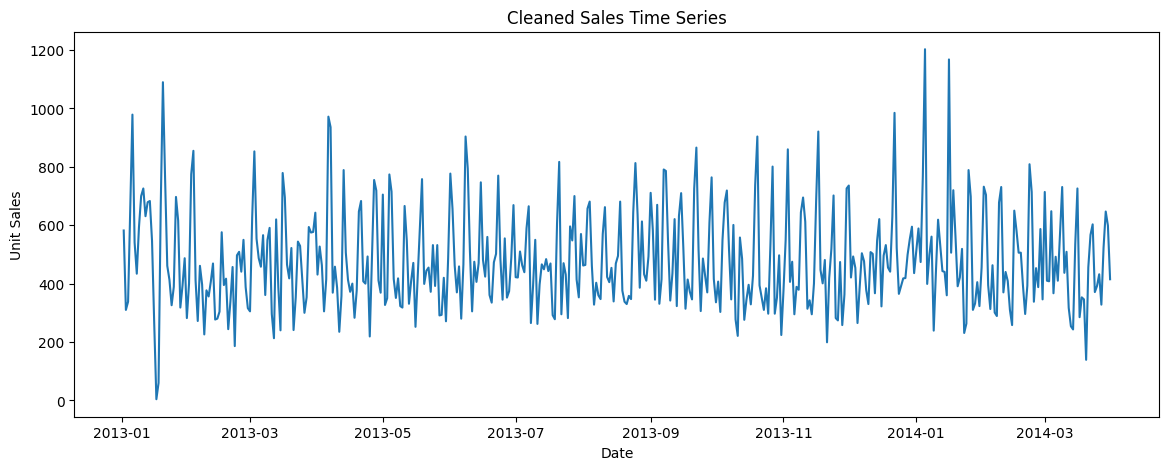

In [198]:
# Plot the cleaned sales time series
plt.figure(figsize=(14, 5))
plt.plot(timeseries.index, timeseries["unit_sales"])
plt.title("Cleaned Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.show()

# 4. Time Series Decomposition

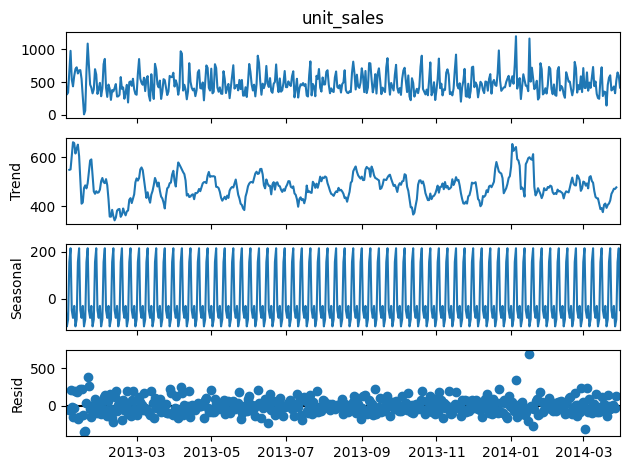

In [199]:
# Decompose the time series into trend, seasonality, and residuals
decomposition = seasonal_decompose(timeseries["unit_sales"], model="additive", period=7)

# Plot the decomposition components
decomposition.plot()
plt.show()

# 5. Stationarity Check

In [200]:
# Perform the Augmented Dickey-Fuller test
adf_result = adfuller(timeseries["unit_sales"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -5.0086145048438455
p-value: 2.133821830904239e-05
Critical Values:
   1%: -3.4454725477848998
   5%: -2.8682072297316794
   10%: -2.570321396485665


The ADF test suggests that the time series is likely stationary, because the p-value is below 0.05. This means we can proceed with statistical modeling without applying an additional differencing step at this stage.

# 6. Autocorrelation Analysis

<Figure size 1000x400 with 0 Axes>

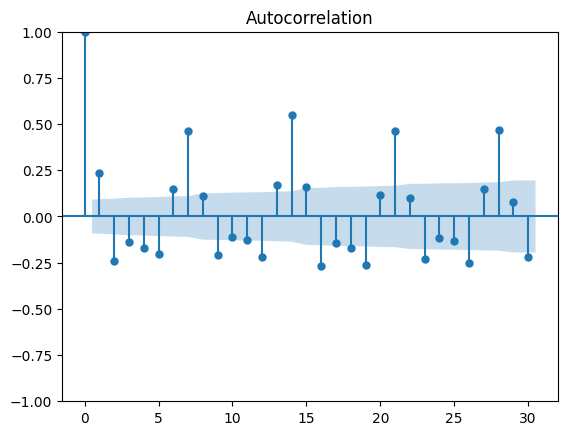

In [201]:
# Plot the autocorrelation function (ACF)
plt.figure(figsize=(10, 4))
plot_acf(timeseries["unit_sales"], lags=30)
plt.show()

<Figure size 1000x400 with 0 Axes>

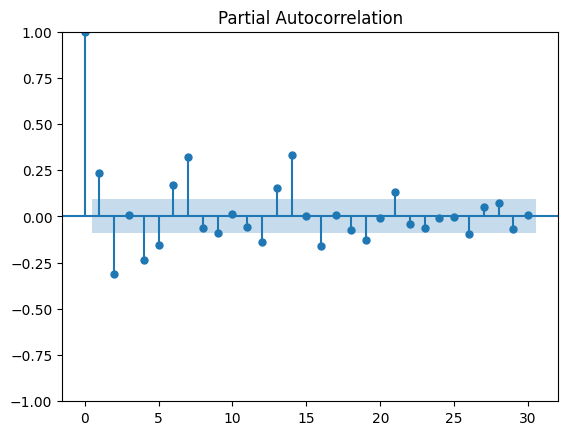

In [202]:
# Plot the partial autocorrelation function (PACF)
plt.figure(figsize=(10, 4))
plot_pacf(timeseries["unit_sales"], lags=30)
plt.show()

The ACF and PACF plots show several significant spikes, including a visible repeating weekly pattern. This suggests that autoregressive and seasonal components may be useful in the statistical forecasting models.

# 7. Exploratory Analysis for Statistical Modelling

This section explores a few additional patterns in the sales series that may help interpret the behavior of the data before fitting statistical forecasting models.

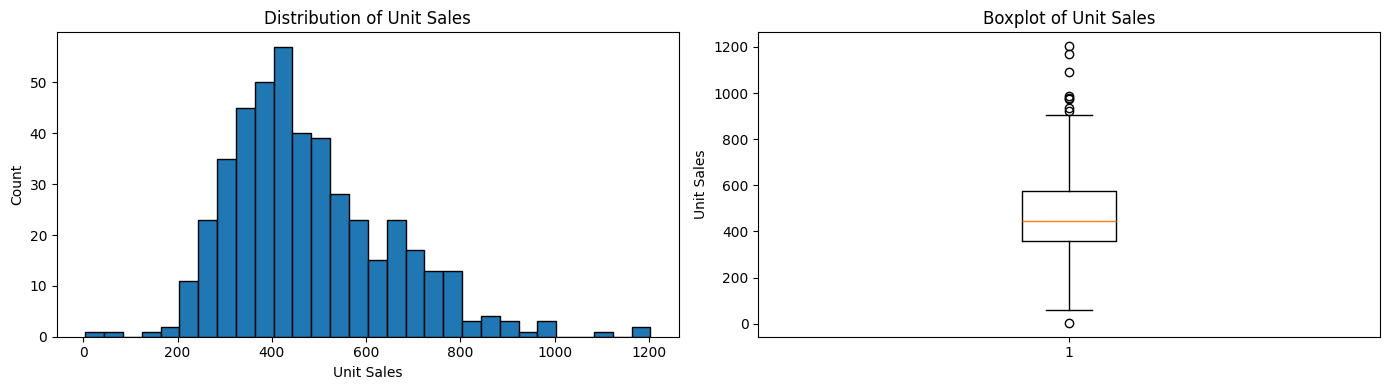

In [203]:
# Plot the distribution and boxplot of unit sales
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.hist(timeseries["unit_sales"], bins=30, edgecolor="black")
plt.title("Distribution of Unit Sales")
plt.xlabel("Unit Sales")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.boxplot(timeseries["unit_sales"])
plt.title("Boxplot of Unit Sales")
plt.ylabel("Unit Sales")

plt.tight_layout()
plt.show()

The sales distribution is right-skewed, with most observations concentrated in the mid-range and a smaller number of high-sales days. The boxplot also shows several upper outliers, which suggests that occasional sales spikes are present in the series.

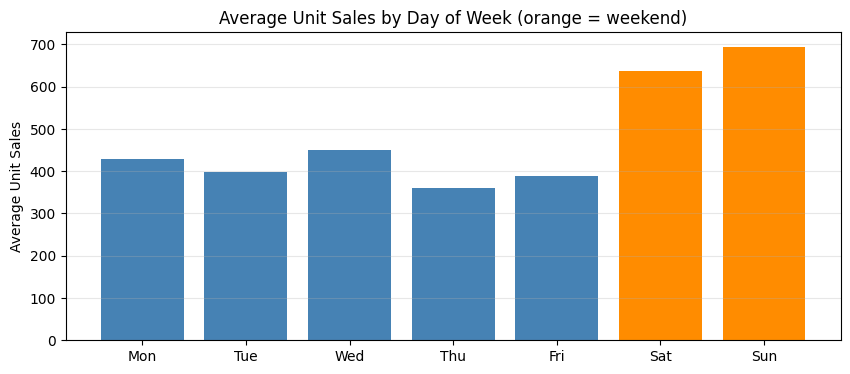

In [204]:
# Create a day-of-week column for exploratory analysis
timeseries["day_of_week"] = timeseries.index.dayofweek

# Calculate average sales by day of week
avg_sales_by_day = timeseries.groupby("day_of_week")["unit_sales"].mean()

# Define day labels and colors
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
bar_colors = ["steelblue", "steelblue", "steelblue", "steelblue", "steelblue", "darkorange", "darkorange"]

# Plot average sales by day of week
plt.figure(figsize=(10, 4))
plt.bar(day_labels, avg_sales_by_day.values, color=bar_colors)
plt.title("Average Unit Sales by Day of Week (orange = weekend)")
plt.xlabel("")
plt.ylabel("Average Unit Sales")
plt.grid(axis="y", alpha=0.3)
plt.show()

Average sales vary noticeably across the week. The highest values appear on Saturday and Sunday, which suggests a strong weekend effect in the sales series.

Next, I check whether oil prices show a visible relationship with sales over time.

In [205]:
# Load the processed oil dataset for exploratory analysis
oil = pd.read_csv("../../data/processed/oil_interpolated.csv")

# Convert the oil date column to datetime
oil["date"] = pd.to_datetime(oil["date"])

In [206]:
# Merge the sales series with oil prices for exploratory analysis
sales_oil = timeseries.reset_index().merge(
    oil[["date", "oil_price_interpolated"]],
    on="date",
    how="left"
)

# Fill missing oil values after the merge
sales_oil["oil_price_interpolated"] = sales_oil["oil_price_interpolated"].ffill()

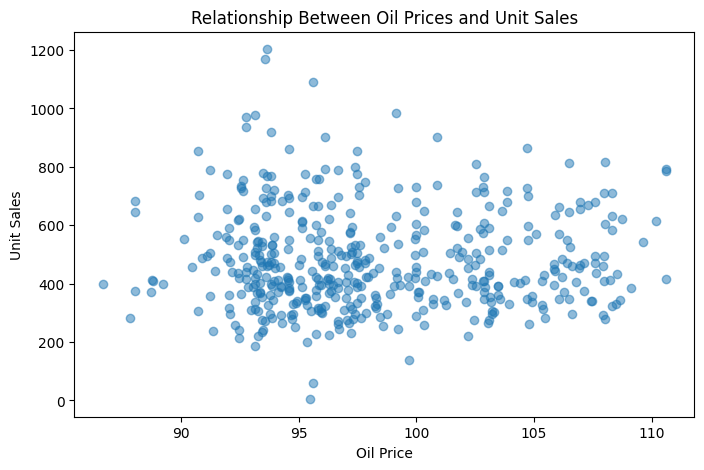

In [207]:
# Plot the relationship between oil prices and unit sales
plt.figure(figsize=(8, 5))
plt.scatter(
    sales_oil["oil_price_interpolated"],
    sales_oil["unit_sales"],
    alpha=0.5
)
plt.title("Relationship Between Oil Prices and Unit Sales")
plt.xlabel("Oil Price")
plt.ylabel("Unit Sales")
plt.show()

The scatter plot does not show a strong linear relationship between oil prices and unit sales. Any effect of oil prices on sales is likely to be weak, indirect, or mixed with other factors.

In [208]:
# Check correlations between numeric variables
sales_oil[["unit_sales", "oil_price_interpolated"]].corr()

,unit_sales,oil_price_interpolated
unit_sales,1.000000,0.003969
oil_price_interpolated,0.003969,1.000000


# 8. Train-Test Split

In [209]:
# Split the time series into train and test sets using the official project periods
train = timeseries.loc["2013-01-01":"2013-12-31"].copy()
test = timeseries.loc["2014-01-01":"2014-03-31"].copy()

In [210]:
# Check the shape and date range of the train and test sets
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

Train shape: (364, 2)
Test shape: (90, 2)
Train period: 2013-01-02 00:00:00 to 2013-12-31 00:00:00
Test period: 2014-01-01 00:00:00 to 2014-03-31 00:00:00


The test period contains 90 daily observations from 2014-01-01 to 2014-03-31. This matches the official project evaluation window.

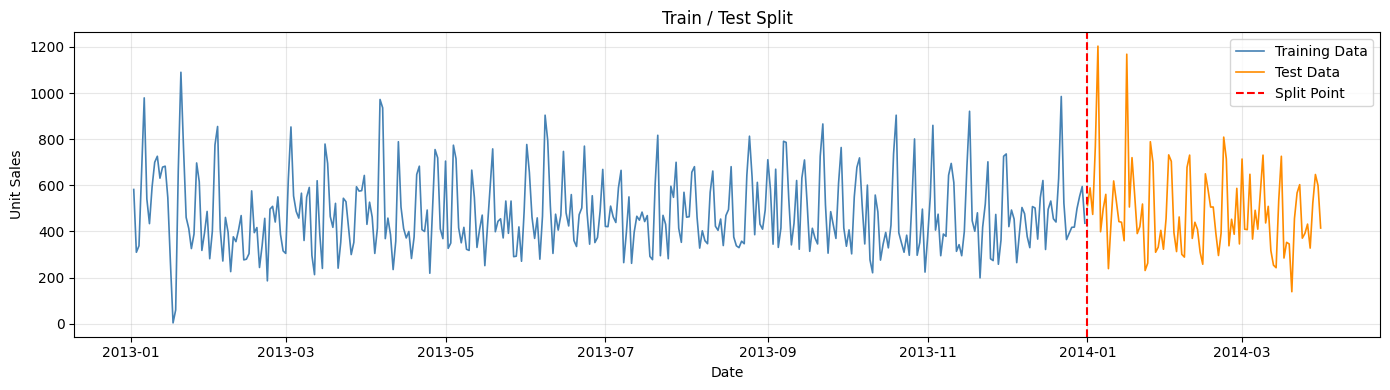

In [211]:
# Visualize the train-test split
plt.figure(figsize=(14, 4))
plt.plot(train.index, train["unit_sales"], label="Training Data", color="steelblue", linewidth=1.2)
plt.plot(test.index, test["unit_sales"], label="Test Data", color="darkorange", linewidth=1.2)
plt.axvline(x=test.index.min(), color="red", linestyle="--", linewidth=1.5, label="Split Point")
plt.title("Train / Test Split")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Check Stationarity on the Training Series

The earlier stationarity and autocorrelation checks were used for general exploration of the full series. At this stage, the same diagnostics are repeated on the training period only, so that the model choice is based strictly on the training data.

In [212]:
# Define a helper function to check stationarity with the ADF test
def check_stationarity(series, name):
    result = adfuller(series.dropna())
    p_value = result[1]

    print("ADF Test —", name)
    print("  p-value:", round(p_value, 4))

    if p_value <= 0.05:
        print("  Result: Stationary — ready for ARIMA/SARIMAX")
    else:
        print("  Result: Not stationary — differencing may be needed")

    print()

# Test the training sales series
check_stationarity(train["unit_sales"], "unit_sales (training)")

ADF Test — unit_sales (training)
  p-value: 0.0006
  Result: Stationary — ready for ARIMA/SARIMAX



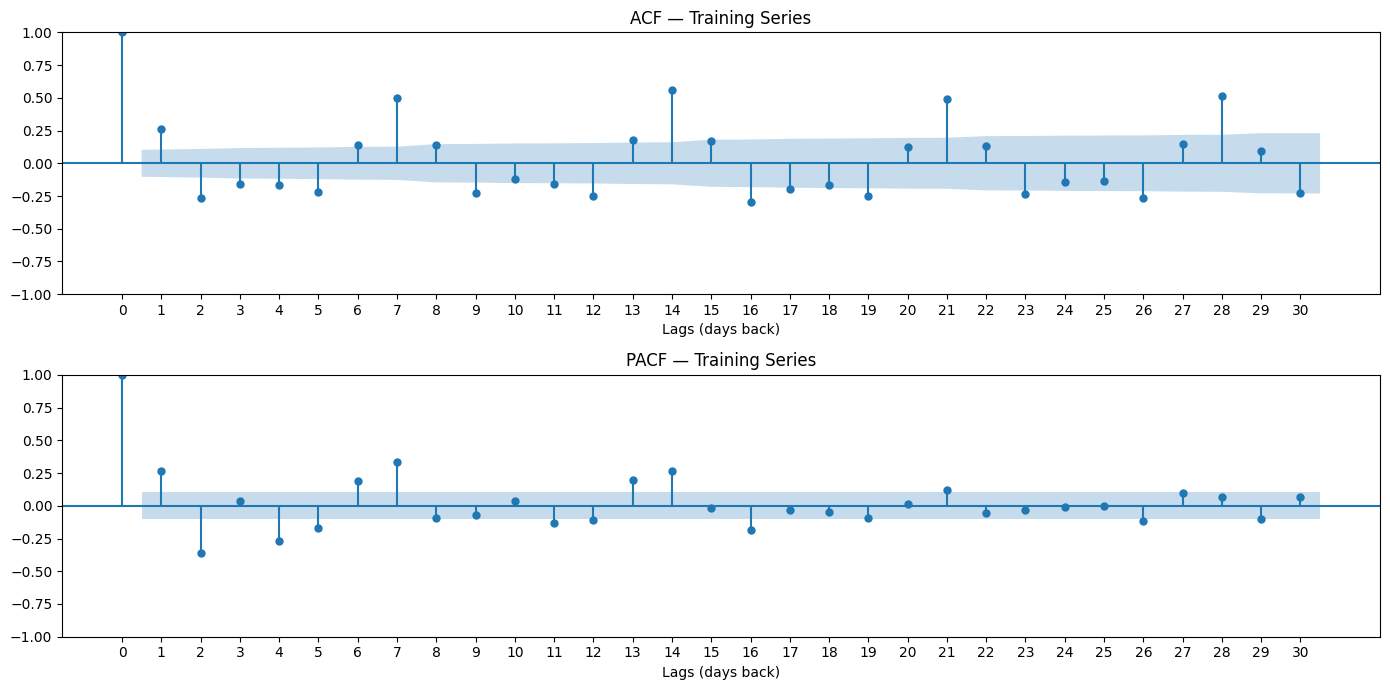

In [213]:
# Plot ACF and PACF for the training series with every lag shown on the x-axis
series = train["unit_sales"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ACF
plot_acf(series, lags=30, ax=axes[0])
axes[0].set_title("ACF — Training Series")
axes[0].set_xlabel("Lags (days back)")
axes[0].set_xticks(range(0, 31, 1))

# PACF
plot_pacf(series, lags=30, ax=axes[1])
axes[1].set_title("PACF — Training Series")
axes[1].set_xlabel("Lags (days back)")
axes[1].set_xticks(range(0, 31, 1))

plt.tight_layout()
plt.show()

The ACF and PACF plots show that the training series still contains meaningful autocorrelation. Several spikes remain outside the confidence bands, especially at lag 1 and around lag 7. This suggests that past values are informative for forecasting and that a weekly seasonal component should be considered in the SARIMAX model.

How to read these plots:

- PACF helps identify the autoregressive part of the model.
- ACF helps identify the moving average part of the model.
- A visible spike around lag 7 suggests a weekly seasonal pattern and supports the use of a seasonal component.

# 10. Prepare Exogenous Features for SARIMAX

In [214]:
# Prepare the base dataframe for SARIMAX exogenous features
sarimax_df = pd.read_csv("../../data/processed/feature_engineered_timeseries.csv")

# Convert the date column to datetime
sarimax_df["date"] = pd.to_datetime(sarimax_df["date"])

In [215]:
# Select the exogenous features used in the SARIMAX model
exog_cols = [
    "oil_price_interpolated",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "is_weekend"
]

In [216]:
# Split the feature-based dataframe into train and test periods
train_exog_df = sarimax_df[(sarimax_df["date"] >= "2013-01-01") & (sarimax_df["date"] <= "2013-12-31")].copy()
test_exog_df = sarimax_df[(sarimax_df["date"] >= "2014-01-01") & (sarimax_df["date"] <= "2014-03-31")].copy()

In [217]:
# Keep only the selected exogenous columns
exog_train = train_exog_df[exog_cols].copy()
exog_test = test_exog_df[exog_cols].copy()

In [218]:
# Check the shape of the exogenous feature sets
print("Training exog shape:", exog_train.shape)
print("Test exog shape:", exog_test.shape)

print("\nFirst 5 rows of training exogenous features:")
display(exog_train.head())

Training exog shape: (334, 5)
Test exog shape: (90, 5)

First 5 rows of training exogenous features:


,oil_price_interpolated,is_national_holiday,is_regional_holiday,is_local_holiday,is_weekend
0,97.46,0,0,0,0
1,97.46,0,0,0,1
2,97.46,0,0,0,1
3,96.21,0,0,0,0
4,96.68,0,0,0,0


In [219]:
# Verify that the target series and exogenous features have matching lengths
print("Train target length:", len(train))
print("Train exog length:", len(exog_train))

print("Test target length:", len(test))
print("Test exog length:", len(exog_test))

Train target length: 364
Train exog length: 334
Test target length: 90
Test exog length: 90


The exogenous feature dataframe does not align with the target training series, because it was created after dropping rows with missing lag and rolling features. For SARIMAX, the exogenous variables must match the target series row by row, so a separate aligned exogenous dataframe will be prepared next.

In [220]:
# Build an aligned exogenous dataframe directly from the cleaned time series dates
sarimax_exog_df = timeseries.reset_index()[["date"]].copy()

# Ensure the date column is in datetime format
sarimax_exog_df["date"] = pd.to_datetime(sarimax_exog_df["date"])

# Add weekend flag
sarimax_exog_df["is_weekend"] = sarimax_exog_df["date"].dt.dayofweek.isin([5, 6]).astype(int)

In [221]:
# Load external datasets for aligned SARIMAX exogenous features
oil = pd.read_csv("../../data/processed/oil_interpolated.csv")
holidays = pd.read_csv("../../data/raw/holidays.csv")

# Convert date columns to datetime
oil["date"] = pd.to_datetime(oil["date"])
holidays["date"] = pd.to_datetime(holidays["date"])

In [222]:
# Merge oil prices into the aligned SARIMAX exogenous dataframe
sarimax_exog_df = sarimax_exog_df.merge(
    oil[["date", "oil_price_interpolated"]],
    on="date",
    how="left"
)

# Fill missing oil values after the merge
sarimax_exog_df["oil_price_interpolated"] = sarimax_exog_df["oil_price_interpolated"].ffill().bfill()

In [223]:
# Create aligned holiday flags directly in the SARIMAX exogenous dataframe

national_holiday_dates = holidays.loc[
    holidays["locale"] == "National", "date"
].drop_duplicates()

regional_holiday_dates = holidays.loc[
    holidays["locale"] == "Regional", "date"
].drop_duplicates()

local_holiday_dates = holidays.loc[
    holidays["locale"] == "Local", "date"
].drop_duplicates()

sarimax_exog_df["is_national_holiday"] = (
    sarimax_exog_df["date"].isin(national_holiday_dates).astype(int)
)

sarimax_exog_df["is_regional_holiday"] = (
    sarimax_exog_df["date"].isin(regional_holiday_dates).astype(int)
)

sarimax_exog_df["is_local_holiday"] = (
    sarimax_exog_df["date"].isin(local_holiday_dates).astype(int)
)

In [224]:
# Check that holiday flag creation did not change the SARIMAX dataframe structure

print("SARIMAX exogenous dataframe shape:", sarimax_exog_df.shape)
print("Duplicate dates:", sarimax_exog_df["date"].duplicated().sum())

print("\nHoliday flag sums:")
print(sarimax_exog_df[
    ["is_national_holiday", "is_regional_holiday", "is_local_holiday"]
].sum())

SARIMAX exogenous dataframe shape: (454, 6)
Duplicate dates: 0

Holiday flag sums:
is_national_holiday    24
is_regional_holiday     4
is_local_holiday       24
dtype: int64


In [225]:
# Display the first rows of the aligned SARIMAX exogenous dataframe
sarimax_exog_df.head()

,date,is_weekend,oil_price_interpolated,is_national_holiday,is_regional_holiday,is_local_holiday
0,2013-01-02,0,93.14,0,0,0
1,2013-01-03,0,92.97,0,0,0
2,2013-01-04,0,93.12,0,0,0
3,2013-01-05,1,93.12,1,0,0
4,2013-01-06,1,93.12,0,0,0


In [226]:
# Select the aligned exogenous columns for SARIMAX
exog_cols = [
    "oil_price_interpolated",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "is_weekend"
]

In [227]:
# Split the aligned SARIMAX exogenous dataframe into train and test sets
exog_train = sarimax_exog_df[
    (sarimax_exog_df["date"] >= "2013-01-01") & (sarimax_exog_df["date"] <= "2013-12-31")
][exog_cols].copy()

exog_test = sarimax_exog_df[
    (sarimax_exog_df["date"] >= "2014-01-01") & (sarimax_exog_df["date"] <= "2014-03-31")
][exog_cols].copy()

In [228]:
# Verify that the aligned exogenous features now match the target series lengths
print("Train target length:", len(train))
print("Train exog length:", len(exog_train))

print("Test target length:", len(test))
print("Test exog length:", len(exog_test))

Train target length: 364
Train exog length: 364
Test target length: 90
Test exog length: 90


In [229]:
# Check missing values in final SARIMAX exogenous features

print("Missing values in SARIMAX exogenous features:")
print(sarimax_exog_df.isna().sum())

Missing values in SARIMAX exogenous features:
date                      0
is_weekend                0
oil_price_interpolated    0
is_national_holiday       0
is_regional_holiday       0
is_local_holiday          0
dtype: int64


# 11. Model 1 — SARIMAX with Exogenous Features

In this section, I train the first statistical forecasting model using the training period and evaluate its predictions on the test period.

In [230]:
# Align the exogenous feature indices with the target series indices
exog_train.index = train.index
exog_test.index = test.index

In [231]:
# Train the first SARIMAX model with exogenous features
model_1 = SARIMAX(
    train["unit_sales"],
    exog=exog_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 7)
)

model_1_fit = model_1.fit(disp=False)

In [232]:
# Display the summary of the fitted SARIMAX model
print(model_1_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                        unit_sales   No. Observations:                  364
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 7)   Log Likelihood               -2238.176
Date:                           Sat, 02 May 2026   AIC                           4496.352
Time:                                   14:31:33   BIC                           4535.324
Sample:                               01-02-2013   HQIC                          4511.841
                                    - 12-31-2013                                         
Covariance Type:                             opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
oil_price_interpolated     4.0476      0.233     17.384      0.000       3.591       4.504
is_nati

In [233]:
# Generate out-of-sample forecasts for the full test period using exogenous features
forecast_1 = model_1_fit.forecast(steps=len(test), exog=exog_test)

In [234]:
# Align the forecast index with the test period dates
forecast_1.index = test.index

In [235]:
# Show forecast summary before plotting
print(f"Forecast generated for {len(forecast_1)} days.\n")

print("First 5 predictions:")
print(forecast_1.head())

Forecast generated for 90 days.

First 5 predictions:
date
2014-01-01    461.693704
2014-01-02    345.421469
2014-01-03    371.163265
2014-01-04    597.079622
2014-01-05    677.668398
Name: predicted_mean, dtype: float64


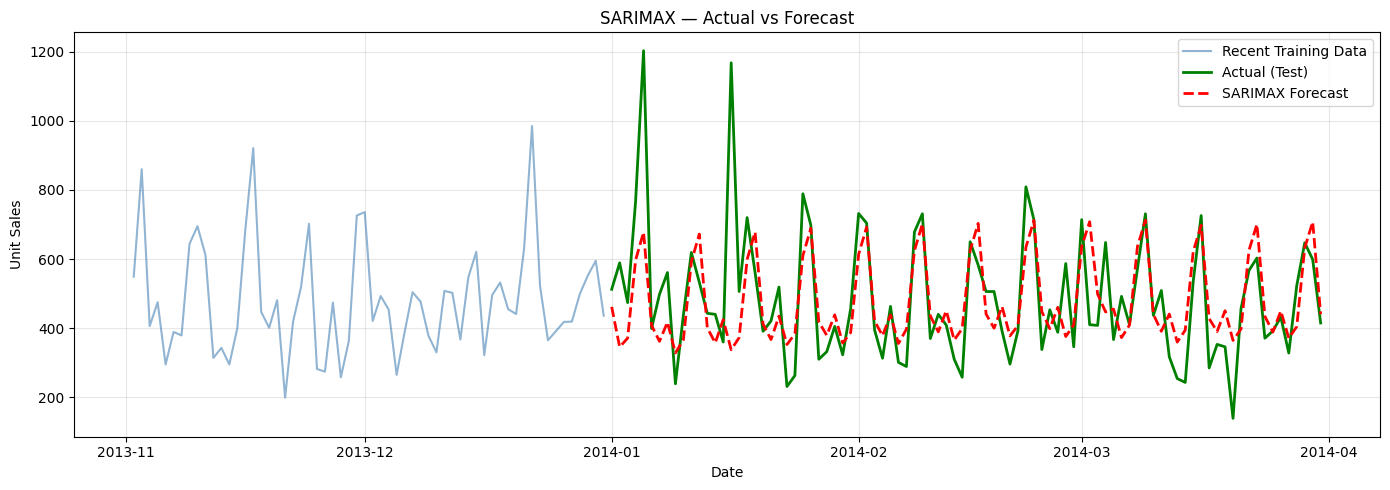

In [236]:
# Plot recent training data, actual test values, and SARIMAX forecast
plt.figure(figsize=(14, 5))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=1.5,
    alpha=0.6
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2
)

plt.plot(
    forecast_1.index,
    forecast_1.values,
    label="SARIMAX Forecast",
    color="red",
    linewidth=2,
    linestyle="--"
)

plt.title("SARIMAX — Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [237]:
# Calculate evaluation metrics for the first SARIMAX model
mae_1 = mean_absolute_error(test["unit_sales"], forecast_1)
rmse_1 = mean_squared_error(test["unit_sales"], forecast_1) ** 0.5
r2_1 = r2_score(test["unit_sales"], forecast_1)
mape_1 = mean_absolute_percentage_error(test["unit_sales"], forecast_1)

print("SARIMAX Model — Evaluation Metrics:\n")

print(f"MAE   (Mean Absolute Error)      : {mae_1:.2f} units")
print("  -> Average absolute difference between forecast and actual\n")

print(f"RMSE  (Root Mean Squared Error) : {rmse_1:.2f} units")
print("  -> Like MAE but penalises large errors more heavily\n")

print(f"MAPE  (Mean Absolute % Error)   : {mape_1 * 100:.2f} %")
print("  -> Average percentage error\n")

print(f"R²    (Coefficient of Determination): {r2_1:.3f}")
print("  -> How much variance the model explains")

SARIMAX Model — Evaluation Metrics:

MAE   (Mean Absolute Error)      : 96.57 units
  -> Average absolute difference between forecast and actual

RMSE  (Root Mean Squared Error) : 144.43 units
  -> Like MAE but penalises large errors more heavily

MAPE  (Mean Absolute % Error)   : 21.54 %
  -> Average percentage error

R²    (Coefficient of Determination): 0.380
  -> How much variance the model explains


The SARIMAX model captures part of the recurring sales pattern and achieves a moderate forecasting performance on the January–March 2014 test period.

The RMSE is higher than the MAE, which suggests that the model still struggles with larger forecast errors on some days. The MAPE of about 21.5% shows that the average percentage error is still relatively high, but the model provides a useful statistical benchmark for comparison with other forecasting approaches.

# 12. Model 2 — Holt-Winters (Triple Exponential Smoothing)

Holt-Winters is a statistical forecasting method that models a time series using level, trend, and seasonality. Unlike SARIMAX, it does not use external variables such as oil prices or holiday flags. It only learns patterns from the target sales series itself.

In [238]:
# Holt-Winters requires a clean series with no NaN values and the seasonal_periods must match the actual cycle in the data

# Our data is daily with a strong weekly cycle -> seasonal_periods=7

print("Fitting Holt-Winters Additive model...")
hw_add = ExponentialSmoothing(
    train["unit_sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
)
hw_add_fit = hw_add.fit(
    smoothing_level=0.3,
    smoothing_trend=0.01,
    smoothing_seasonal=0.3,
    optimized=False
)

print("Fitting Holt-Winters Multiplicative model...")
hw_mul = ExponentialSmoothing(
    train["unit_sales"],
    trend="add",
    seasonal="mul",
    seasonal_periods=7
)
hw_mul_fit = hw_mul.fit(
    smoothing_level=0.3,
    smoothing_trend=0.01,
    smoothing_seasonal=0.3,
    optimized=False
)

print()
print("Both models fitted successfully!")
print()

print("Additive model parameters chosen automatically:")
print("  Alpha (level)   :", round(hw_add_fit.params["smoothing_level"], 4))
print("  Beta (trend)    :", round(hw_add_fit.params["smoothing_trend"], 4))
print("  Gamma (seasonal):", round(hw_add_fit.params["smoothing_seasonal"], 4))
print()

print("Multiplicative model parameters chosen automatically:")
print("  Alpha (level)   :", round(hw_mul_fit.params["smoothing_level"], 4))
print("  Beta (trend)    :", round(hw_mul_fit.params["smoothing_trend"], 4))
print("  Gamma (seasonal):", round(hw_mul_fit.params["smoothing_seasonal"], 4))

Fitting Holt-Winters Additive model...
Fitting Holt-Winters Multiplicative model...

Both models fitted successfully!

Additive model parameters chosen automatically:
  Alpha (level)   : 0.3
  Beta (trend)    : 0.01
  Gamma (seasonal): 0.3

Multiplicative model parameters chosen automatically:
  Alpha (level)   : 0.3
  Beta (trend)    : 0.01
  Gamma (seasonal): 0.3


The optimized smoothing parameters are extremely close to zero for both Holt-Winters variants. This suggests that the model relies mostly on the stable structure already estimated from the training series, with only minimal updating of level, trend, and seasonality over time.

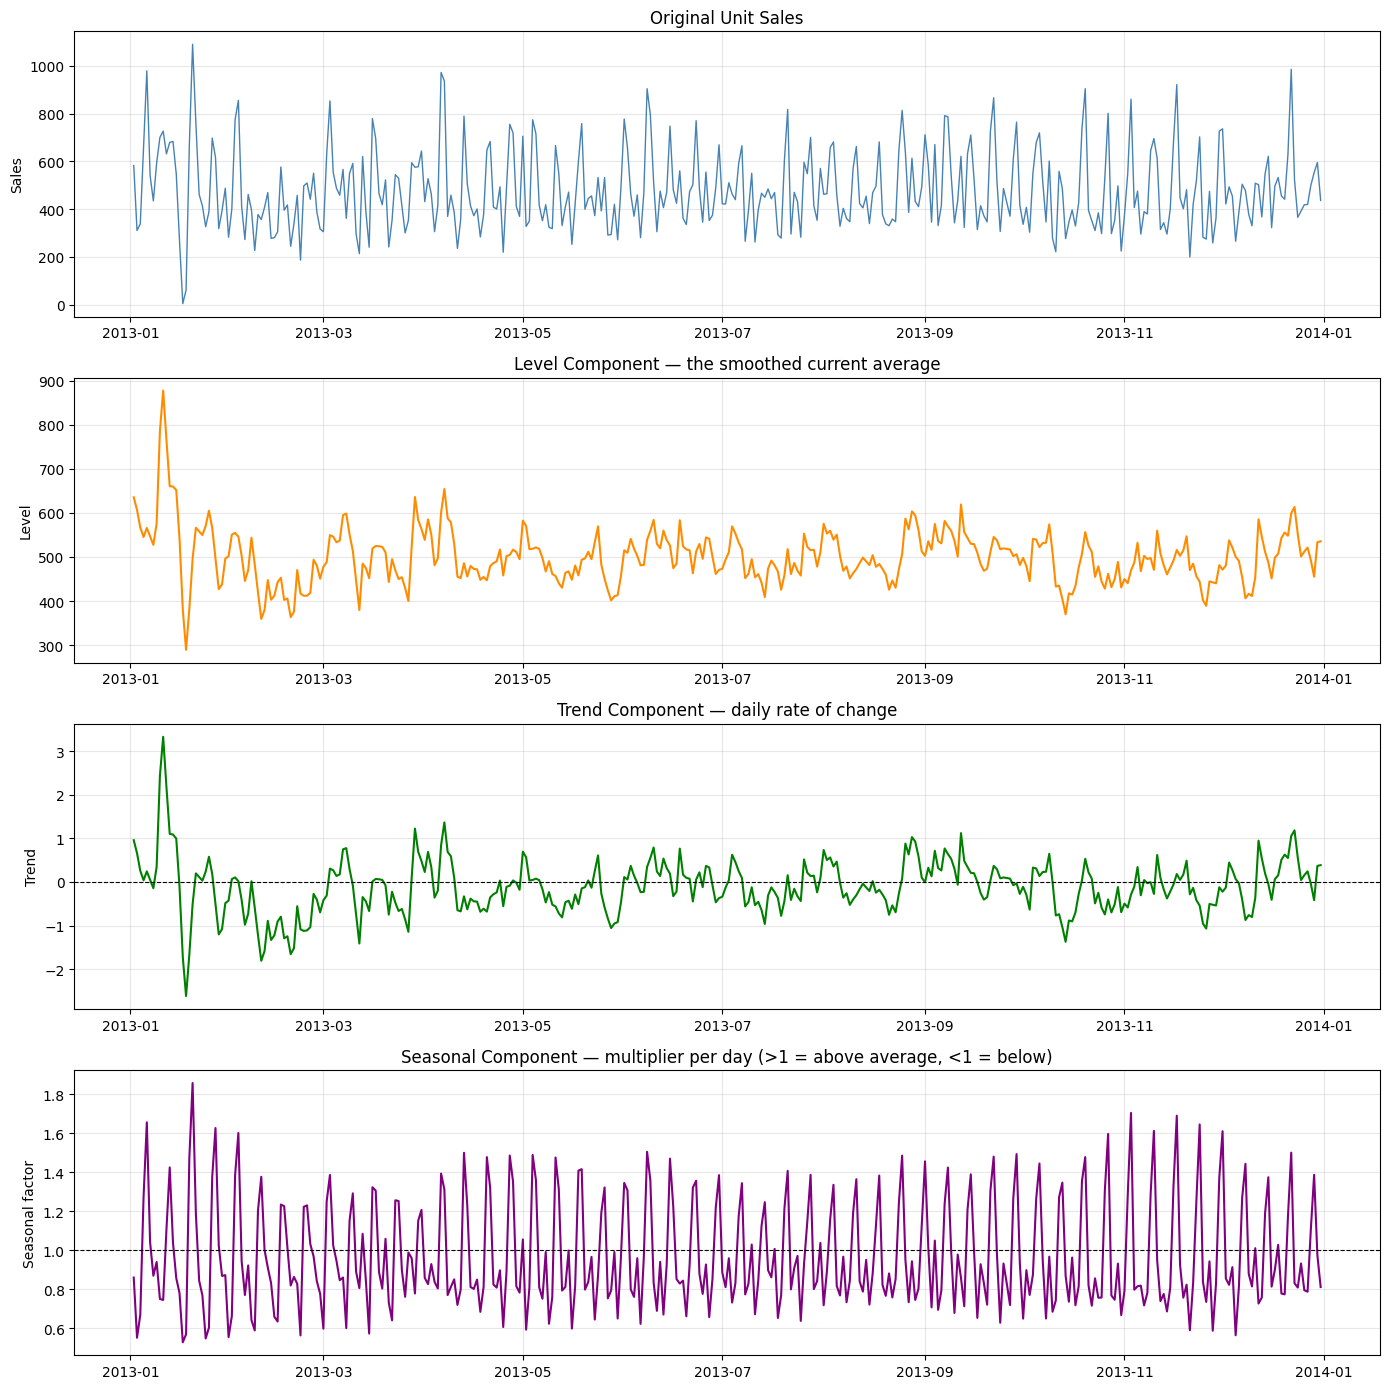

In [239]:
# Visualise the three internal components learned by the multiplicative model

fig, axes = plt.subplots(4, 1, figsize=(14, 14))

# 1. Original sales series
axes[0].plot(train.index, train["unit_sales"], color="steelblue", linewidth=1)
axes[0].set_title("Original Unit Sales")
axes[0].set_ylabel("Sales")
axes[0].grid(True, alpha=0.3)

# 2. Level component
axes[1].plot(train.index, hw_mul_fit.level, color="darkorange", linewidth=1.5)
axes[1].set_title("Level Component — the smoothed current average")
axes[1].set_ylabel("Level")
axes[1].grid(True, alpha=0.3)

# 3. Trend component
axes[2].plot(train.index, hw_mul_fit.trend, color="green", linewidth=1.5)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Trend Component — daily rate of change")
axes[2].set_ylabel("Trend")
axes[2].grid(True, alpha=0.3)

# 4. Seasonal component
axes[3].plot(train.index, hw_mul_fit.season, color="purple", linewidth=1.5)
axes[3].axhline(1, color="black", linestyle="--", linewidth=0.8)
axes[3].set_title("Seasonal Component — multiplier per day (>1 = above average, <1 = below)")
axes[3].set_ylabel("Seasonal factor")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [240]:
# Print the seasonal factor for each day of the week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
seasonal_factors = hw_mul_fit.season[-7:].values

print("Seasonal factors by day of week (multiplicative model):")
print("  > 1.0 = that day tends to be ABOVE the weekly average")
print("  < 1.0 = that day tends to be BELOW the weekly average")
print()

for day, factor in zip(day_names, seasonal_factors):
    bar = "#" * int(abs(factor) * 15)
    print(f"  {day}: {factor:.3f}  {bar}")

Seasonal factors by day of week (multiplicative model):
  > 1.0 = that day tends to be ABOVE the weekly average
  < 1.0 = that day tends to be BELOW the weekly average

  Mon: 0.931  #############
  Tue: 0.794  ###########
  Wed: 0.786  ###########
  Thu: 1.107  ################
  Fri: 1.386  ####################
  Sat: 0.973  ##############
  Sun: 0.810  ############


In [241]:
# Generate forecasts for both Holt-Winters models
forecast_hw_add = hw_add_fit.forecast(steps=len(test))
forecast_hw_mul = hw_mul_fit.forecast(steps=len(test))

# Align forecast indices with the test period
forecast_hw_add.index = test.index
forecast_hw_mul.index = test.index

In [242]:
# Display the first forecasted values from both Holt-Winters models
print("Additive Holt-Winters forecast:")
print(forecast_hw_add.head())
print()

print("Multiplicative Holt-Winters forecast:")
print(forecast_hw_mul.head())

Additive Holt-Winters forecast:
date
2014-01-01    472.214482
2014-01-02    410.632634
2014-01-03    409.445056
2014-01-04    572.003296
2014-01-05    717.152653
dtype: float64

Multiplicative Holt-Winters forecast:
date
2014-01-01    499.251980
2014-01-02    425.964714
2014-01-03    422.140157
2014-01-04    594.831185
2014-01-05    745.079434
dtype: float64


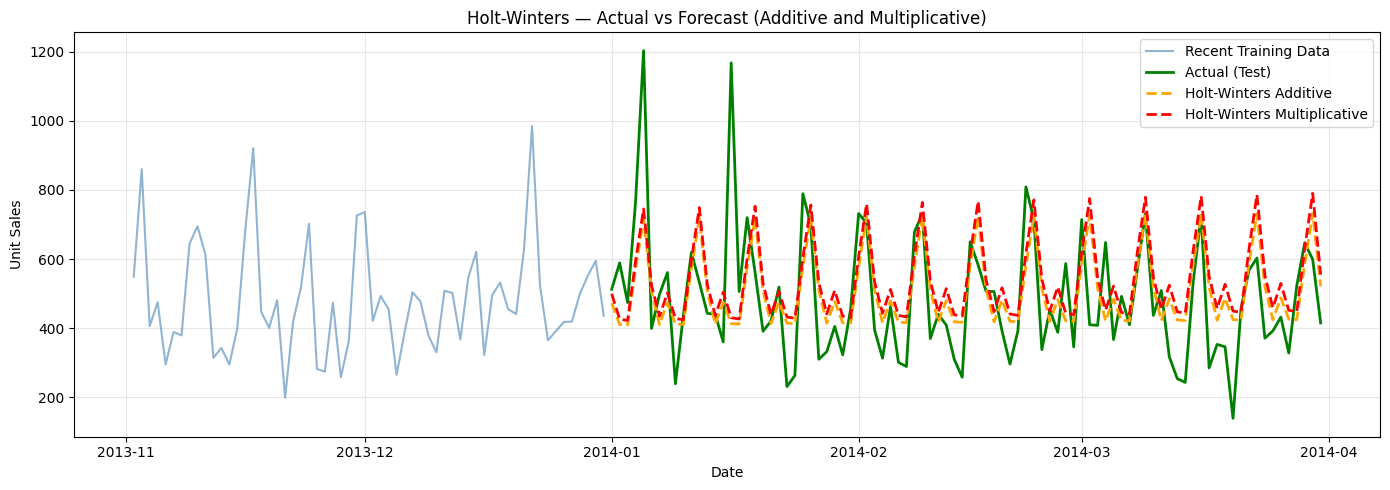

In [243]:
# Plot both Holt-Winters forecasts against actual values in one chart
plt.figure(figsize=(14, 5))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=1.5,
    alpha=0.6
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2
)

plt.plot(
    forecast_hw_add.index,
    forecast_hw_add.values,
    label="Holt-Winters Additive",
    color="orange",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    forecast_hw_mul.index,
    forecast_hw_mul.values,
    label="Holt-Winters Multiplicative",
    color="red",
    linewidth=2,
    linestyle="--"
)

plt.title("Holt-Winters — Actual vs Forecast (Additive and Multiplicative)")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [244]:
# Compare additive and multiplicative Holt-Winters forecasts numerically
hw_diff = (forecast_hw_add - forecast_hw_mul).abs()

print("Maximum absolute difference:", hw_diff.max())
print("Mean absolute difference:", hw_diff.mean())
print()

print("First 10 forecast differences:")
print(hw_diff.head(10))

Maximum absolute difference: 57.4086559449961
Mean absolute difference: 29.063329323388025

First 10 forecast differences:
date
2014-01-01    27.037498
2014-01-02    15.332080
2014-01-03    12.695101
2014-01-04    22.827888
2014-01-05    27.926781
2014-01-06    17.746324
2014-01-07    24.426844
2014-01-08    28.266020
2014-01-09    16.189655
2014-01-10    13.531884
dtype: float64


In [245]:
# Calculate evaluation metrics for both Holt-Winters models
mae_hw_add = mean_absolute_error(test["unit_sales"], forecast_hw_add)
rmse_hw_add = mean_squared_error(test["unit_sales"], forecast_hw_add) ** 0.5
r2_hw_add = r2_score(test["unit_sales"], forecast_hw_add)
mape_hw_add = mean_absolute_percentage_error(test["unit_sales"], forecast_hw_add)

mae_hw_mul = mean_absolute_error(test["unit_sales"], forecast_hw_mul)
rmse_hw_mul = mean_squared_error(test["unit_sales"], forecast_hw_mul) ** 0.5
r2_hw_mul = r2_score(test["unit_sales"], forecast_hw_mul)
mape_hw_mul = mean_absolute_percentage_error(test["unit_sales"], forecast_hw_mul)

print("Holt-Winters Additive — Evaluation Metrics:\n")
print(f"MAE   : {mae_hw_add:.2f}")
print(f"RMSE  : {rmse_hw_add:.2f}")
print(f"MAPE  : {mape_hw_add * 100:.2f} %")
print(f"R²    : {r2_hw_add:.3f}")

print("\n" + "-" * 40 + "\n")

print("Holt-Winters Multiplicative — Evaluation Metrics:\n")
print(f"MAE   : {mae_hw_mul:.2f}")
print(f"RMSE  : {rmse_hw_mul:.2f}")
print(f"MAPE  : {mape_hw_mul * 100:.2f} %")
print(f"R²    : {r2_hw_mul:.3f}")

Holt-Winters Additive — Evaluation Metrics:

MAE   : 113.72
RMSE  : 153.70
MAPE  : 27.37 %
R²    : 0.298

----------------------------------------

Holt-Winters Multiplicative — Evaluation Metrics:

MAE   : 124.60
RMSE  : 161.97
MAPE  : 30.79 %
R²    : 0.220


The additive Holt-Winters model performed better than the multiplicative variant across all evaluation metrics.

The difference suggests that additive seasonality is more suitable for this time series than multiplicative seasonality. However, both Holt-Winters variants still perform worse than the SARIMAX model on the January–March 2014 test period.

# 13. Model 3 — Prophet

Prophet is a forecasting model developed for business time series with trend, seasonality, and holiday effects. It works differently from SARIMAX and Holt-Winters because it models the time series as a combination of interpretable components and requires a dataframe with two specific columns: `ds` for dates and `y` for the target values.

In [276]:
# Prepare the training and test datasets for Prophet
train_prophet = train.reset_index().iloc[:, :2].copy()
test_prophet = test.reset_index().iloc[:, :2].copy()

train_prophet.columns = ["ds", "y"]
test_prophet.columns = ["ds", "y"]

In [277]:
train_prophet.head(), test_prophet.head()

(          ds      y
 0 2013-01-02  582.0
 1 2013-01-03  310.0
 2 2013-01-04  338.0
 3 2013-01-05  654.0
 4 2013-01-06  979.0,
           ds       y
 0 2014-01-01   512.5
 1 2014-01-02   589.0
 2 2014-01-03   474.0
 3 2014-01-04   767.0
 4 2014-01-05  1203.0)

In [278]:
# Build a holiday dataframe for Prophet from the aligned exogenous dataframe
holiday_rows = []

for _, row in sarimax_exog_df.iterrows():
    if row["is_national_holiday"] == 1:
        holiday_rows.append({"holiday": "national_holiday", "ds": row["date"]})
    if row["is_regional_holiday"] == 1:
        holiday_rows.append({"holiday": "regional_holiday", "ds": row["date"]})
    if row["is_local_holiday"] == 1:
        holiday_rows.append({"holiday": "local_holiday", "ds": row["date"]})

holidays_prophet = pd.DataFrame(holiday_rows)

print("Holiday dataframe for Prophet:")
print(holidays_prophet.head(10))
print()
print("Total holiday dates passed to Prophet:", len(holidays_prophet))

Holiday dataframe for Prophet:
            holiday         ds
0  national_holiday 2013-01-05
1  national_holiday 2013-01-12
2  national_holiday 2013-02-11
3  national_holiday 2013-02-12
4     local_holiday 2013-03-02
5  regional_holiday 2013-04-01
6     local_holiday 2013-04-12
7     local_holiday 2013-04-14
8     local_holiday 2013-04-21
9  national_holiday 2013-04-29

Total holiday dates passed to Prophet: 52


In [279]:
# Validate Prophet holiday dataframe

print("Prophet holidays shape:", holidays_prophet.shape)
print("Missing values:")
print(holidays_prophet.isna().sum())

print("\nDate range:")
print(holidays_prophet["ds"].min(), "to", holidays_prophet["ds"].max())

print("\nHoliday types:")
print(holidays_prophet["holiday"].value_counts())

Prophet holidays shape: (52, 2)
Missing values:
holiday    0
ds         0
dtype: int64

Date range:
2013-01-05 00:00:00 to 2014-03-04 00:00:00

Holiday types:
holiday
national_holiday    24
local_holiday       24
regional_holiday     4
Name: count, dtype: int64


The basic Prophet model includes weekly seasonality and holiday effects. Yearly seasonality is disabled because the training period covers approximately one year, which is limited for learning a stable yearly pattern.

In [280]:
# Fit the basic Prophet model
print("Fitting Basic Prophet model...")

model_prophet_basic = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,
    seasonality_mode="additive",
    holidays=holidays_prophet
)

model_prophet_basic.fit(train_prophet)

print("Basic Prophet fitted successfully!")

15:07:17 - cmdstanpy - INFO - Chain [1] start processing


Fitting Basic Prophet model...


15:07:17 - cmdstanpy - INFO - Chain [1] done processing


Basic Prophet fitted successfully!


In [281]:
# Check alignment between Prophet training data and oil regressor
print("Prophet train length:", len(prophet_train_adv))
print("Oil regressor length:", len(exog_train))
print("Missing oil values in Prophet training data:", prophet_train_adv["dcoilwtico"].isna().sum())

Prophet train length: 364
Oil regressor length: 364
Missing oil values in Prophet training data: 0


The advanced Prophet model extends the basic Prophet setup by adding oil price as an external regressor and using a custom weekly seasonality component. This allows the model to test whether external economic information and a more flexible weekly pattern improve forecast accuracy.

In [282]:
# Advanced Prophet - adds oil price as an external regressor
# and uses a higher Fourier order for the weekly seasonality

print("Fitting Advanced Prophet model (with oil price regressor)...")

model_prophet_adv = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    seasonality_mode="additive",
    holidays=holidays_prophet,
    changepoint_prior_scale=0.1
)

# Custom weekly seasonality with higher Fourier order
model_prophet_adv.add_seasonality(
    name="weekly_custom",
    period=7,
    fourier_order=5
)

# Add oil price as an external regressor
# Prophet will learn how much oil price movements affect sales
model_prophet_adv.add_regressor("dcoilwtico")

# Add training data WITH the oil regressor column included
prophet_train_adv = train_prophet.copy()
prophet_train_adv["dcoilwtico"] = exog_train["oil_price_interpolated"].values

model_prophet_adv.fit(prophet_train_adv)

print("Advanced Prophet fitted successfully!")

15:07:17 - cmdstanpy - INFO - Chain [1] start processing
15:07:18 - cmdstanpy - INFO - Chain [1] done processing


Fitting Advanced Prophet model (with oil price regressor)...
Advanced Prophet fitted successfully!


In [283]:
# Create future dataframe for the basic Prophet model
future_basic = model_prophet_basic.make_future_dataframe(
    periods=len(test),
    freq="D"
)

# Generate forecast
forecast_basic = model_prophet_basic.predict(future_basic)

# Extract only the test-period forecast rows
forecast_basic_test = forecast_basic.tail(len(test)).copy()

# Extract only the test-period predictions
prophet_basic_preds = forecast_basic_test["yhat"].values
prophet_basic_preds = prophet_basic_preds.clip(0)

print("Basic Prophet forecasts generated.")
print("Basic Prophet test forecast date range:")
print(forecast_basic_test["ds"].min(), "to", forecast_basic_test["ds"].max())
print("Number of test predictions:", len(prophet_basic_preds))

Basic Prophet forecasts generated.
Basic Prophet test forecast date range:
2014-01-01 00:00:00 to 2014-03-31 00:00:00
Number of test predictions: 90


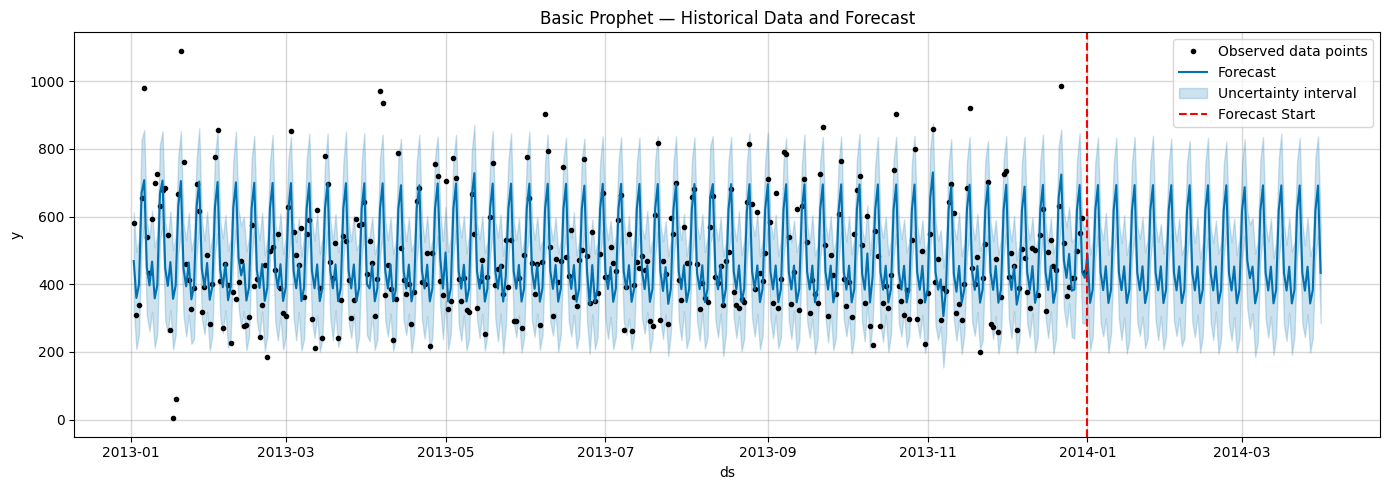

In [284]:
# Plot Prophet's built-in forecast chart (basic model)

fig = model_prophet_basic.plot(forecast_basic, figsize=(14, 5))

plt.title("Basic Prophet — Historical Data and Forecast")

plt.axvline(
    x=test_prophet["ds"].min(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Start"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [285]:
# Create future dataframe for the advanced Prophet model
future_adv = model_prophet_adv.make_future_dataframe(
    periods=len(test),
    freq="D"
)

# Attach oil prices to all dates used by the advanced Prophet model
oil_full = pd.concat(
    [
        exog_train["oil_price_interpolated"],
        exog_test["oil_price_interpolated"]
    ],
    ignore_index=True
)

# Check that the future dataframe and oil regressor have the same length
print("Future dataframe length:", len(future_adv))
print("Oil regressor length:", len(oil_full))

future_adv["dcoilwtico"] = oil_full.values

# Generate forecast
forecast_adv = model_prophet_adv.predict(future_adv)

# Extract only the test-period forecast rows
forecast_adv_test = forecast_adv.tail(len(test)).copy()

# Extract only the test-period predictions
prophet_adv_preds = forecast_adv_test["yhat"].values
prophet_adv_preds = prophet_adv_preds.clip(0)

print("Advanced Prophet forecasts generated.")
print("Advanced Prophet test forecast date range:")
print(forecast_adv_test["ds"].min(), "to", forecast_adv_test["ds"].max())
print("Number of test predictions:", len(prophet_adv_preds))

Future dataframe length: 454
Oil regressor length: 454
Advanced Prophet forecasts generated.
Advanced Prophet test forecast date range:
2014-01-01 00:00:00 to 2014-03-31 00:00:00
Number of test predictions: 90


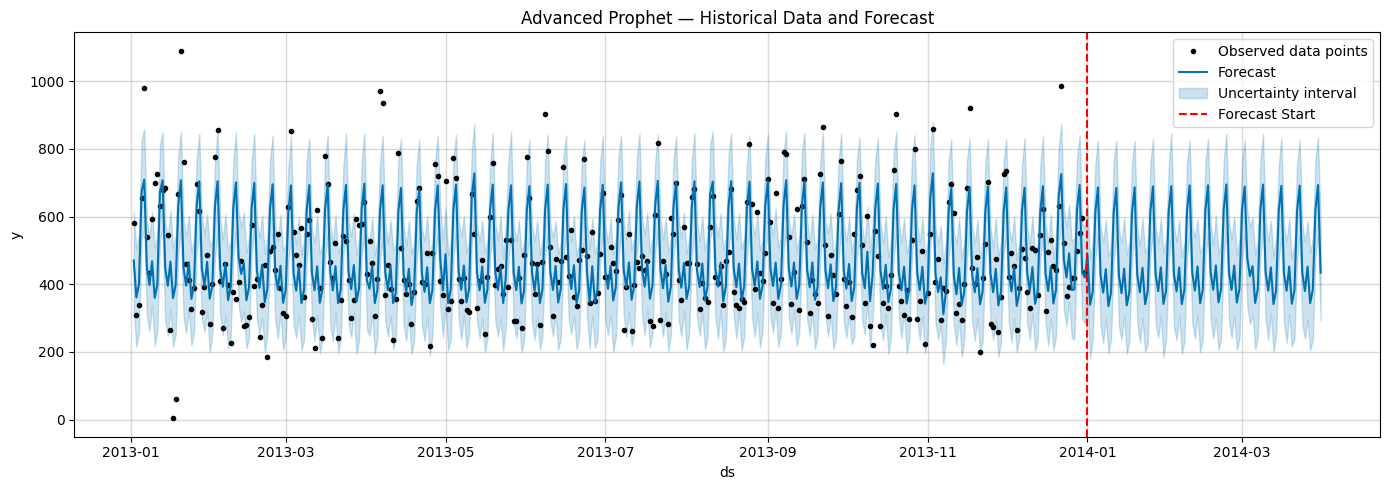

In [286]:
# Plot Prophet's built-in forecast chart (advanced model)

fig = model_prophet_adv.plot(forecast_adv, figsize=(14, 5))

plt.title("Advanced Prophet — Historical Data and Forecast")

plt.axvline(
    x=test_prophet["ds"].min(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Forecast Start"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [287]:
# Extract only the test-period forecast rows

forecast_basic_test = forecast_basic.tail(len(test)).copy()
forecast_adv_test = forecast_adv.tail(len(test)).copy()

print("Basic Prophet test forecast date range:")
print(forecast_basic_test["ds"].min(), "to", forecast_basic_test["ds"].max())

print("\nAdvanced Prophet test forecast date range:")
print(forecast_adv_test["ds"].min(), "to", forecast_adv_test["ds"].max())

Basic Prophet test forecast date range:
2014-01-01 00:00:00 to 2014-03-31 00:00:00

Advanced Prophet test forecast date range:
2014-01-01 00:00:00 to 2014-03-31 00:00:00


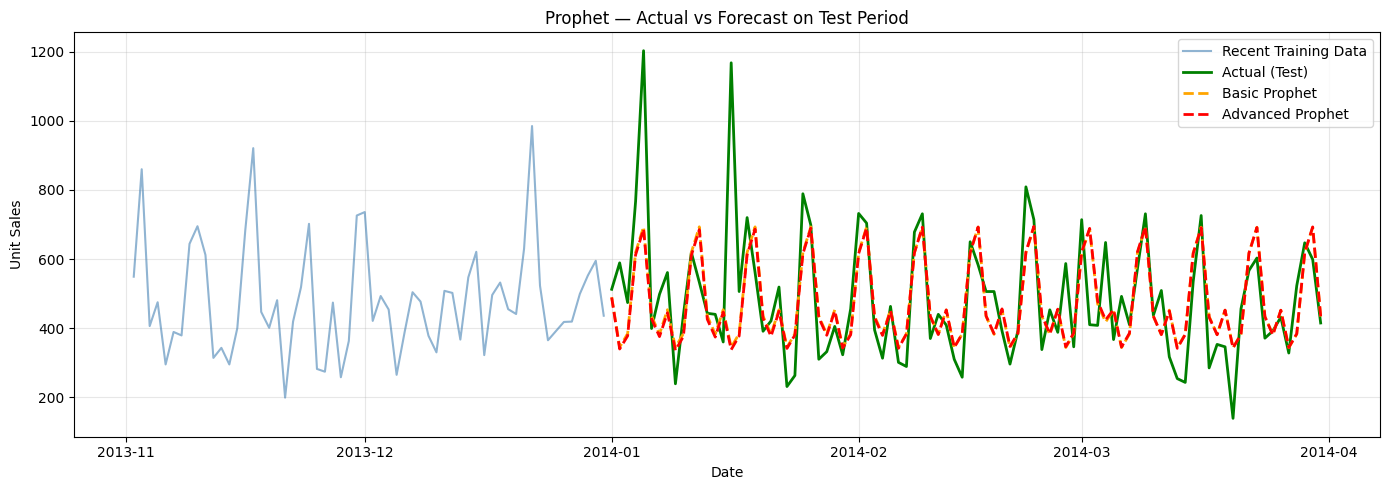

In [288]:
# Plot both Prophet forecasts against the actual test values

plt.figure(figsize=(14, 5))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=1.5,
    alpha=0.6
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2
)

plt.plot(
    forecast_basic_test["ds"],
    forecast_basic_test["yhat"],
    label="Basic Prophet",
    color="orange",
    linewidth=2,
    linestyle="--"
)

plt.plot(
    forecast_adv_test["ds"],
    forecast_adv_test["yhat"],
    label="Advanced Prophet",
    color="red",
    linewidth=2,
    linestyle="--"
)

plt.title("Prophet — Actual vs Forecast on Test Period")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [289]:
# Check prediction lengths before evaluation

print("Test length:", len(test))
print("Basic Prophet predictions:", len(prophet_basic_preds))
print("Advanced Prophet predictions:", len(prophet_adv_preds))

Test length: 90
Basic Prophet predictions: 90
Advanced Prophet predictions: 90


In [290]:
# Evaluate both Prophet variants
def score_prophet_model(name, actual, predictions):
    mae = mean_absolute_error(actual, predictions)
    rmse = mean_squared_error(actual, predictions) ** 0.5
    mape = mean_absolute_percentage_error(actual, predictions) * 100
    r2 = r2_score(actual, predictions)

    print(f"{name}:")
    print(f"  MAE : {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²  : {r2:.4f}")
    print()

    return mae, rmse, mape, r2


actual = test["unit_sales"].values

print("Prophet Evaluation Results:")
print()

basic_prophet_scores = score_prophet_model(
    "Basic Prophet",
    actual,
    prophet_basic_preds
)

advanced_prophet_scores = score_prophet_model(
    "Advanced Prophet",
    actual,
    prophet_adv_preds
)

Prophet Evaluation Results:

Basic Prophet:
  MAE : 94.48
  RMSE: 142.52
  MAPE: 20.80%
  R²  : 0.3963

Advanced Prophet:
  MAE : 94.92
  RMSE: 143.26
  MAPE: 20.78%
  R²  : 0.3900



The Basic Prophet and Advanced Prophet models produced very similar results on the January–March 2014 test period.

The Basic Prophet model performed slightly better in terms of MAE, RMSE, and R², while the Advanced Prophet model had a marginally lower MAPE. This suggests that adding holiday effects and oil price as an external regressor did not lead to a meaningful improvement in forecast accuracy for this dataset.

Both Prophet variants capture the recurring weekly pattern reasonably well, but they remain relatively smooth and still struggle with sharp sales spikes. Compared with Holt-Winters, Prophet performs better, but it remains slightly weaker than the SARIMAX model in this statistical modeling notebook.

# 14. Final Comparison of Statistical Models

In [291]:
# Collect all model scores into one comparison table

all_results = [
    {
        "Model": "SARIMAX + exogenous features",
        "MAE": mae_1,
        "RMSE": rmse_1,
        "MAPE": mape_1 * 100,
        "R2": r2_1
    },
    {
        "Model": "Holt-Winters Additive",
        "MAE": mae_hw_add,
        "RMSE": rmse_hw_add,
        "MAPE": mape_hw_add * 100,
        "R2": r2_hw_add
    },
    {
        "Model": "Holt-Winters Multiplicative",
        "MAE": mae_hw_mul,
        "RMSE": rmse_hw_mul,
        "MAPE": mape_hw_mul * 100,
        "R2": r2_hw_mul
    },
    {
        "Model": "Prophet Basic",
        "MAE": basic_prophet_scores[0],
        "RMSE": basic_prophet_scores[1],
        "MAPE": basic_prophet_scores[2],
        "R2": basic_prophet_scores[3]
    },
    {
        "Model": "Prophet Advanced",
        "MAE": advanced_prophet_scores[0],
        "RMSE": advanced_prophet_scores[1],
        "MAPE": advanced_prophet_scores[2],
        "R2": advanced_prophet_scores[3]
    }
]

results_df = pd.DataFrame(all_results)

results_df["MAE"] = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)
results_df["MAPE"] = results_df["MAPE"].round(2)
results_df["R2"] = results_df["R2"].round(4)

# Sort models by RMSE because RMSE is the main comparison metric
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

print("Performance Comparison — All Statistical Models on the Same Test Set:")
print()
print(results_df.to_string(index=False))
print()

print("Best MAE :", results_df.loc[results_df["MAE"].idxmin(), "Model"])
print("Best RMSE:", results_df.loc[results_df["RMSE"].idxmin(), "Model"])
print("Best R2  :", results_df.loc[results_df["R2"].idxmax(), "Model"])

Performance Comparison — All Statistical Models on the Same Test Set:

                       Model    MAE   RMSE  MAPE     R2
               Prophet Basic  94.48 142.52 20.80 0.3963
            Prophet Advanced  94.92 143.26 20.78 0.3900
SARIMAX + exogenous features  96.57 144.43 21.54 0.3800
       Holt-Winters Additive 113.72 153.70 27.37 0.2978
 Holt-Winters Multiplicative 124.60 161.97 30.79 0.2203

Best MAE : Prophet Basic
Best RMSE: Prophet Basic
Best R2  : Prophet Basic


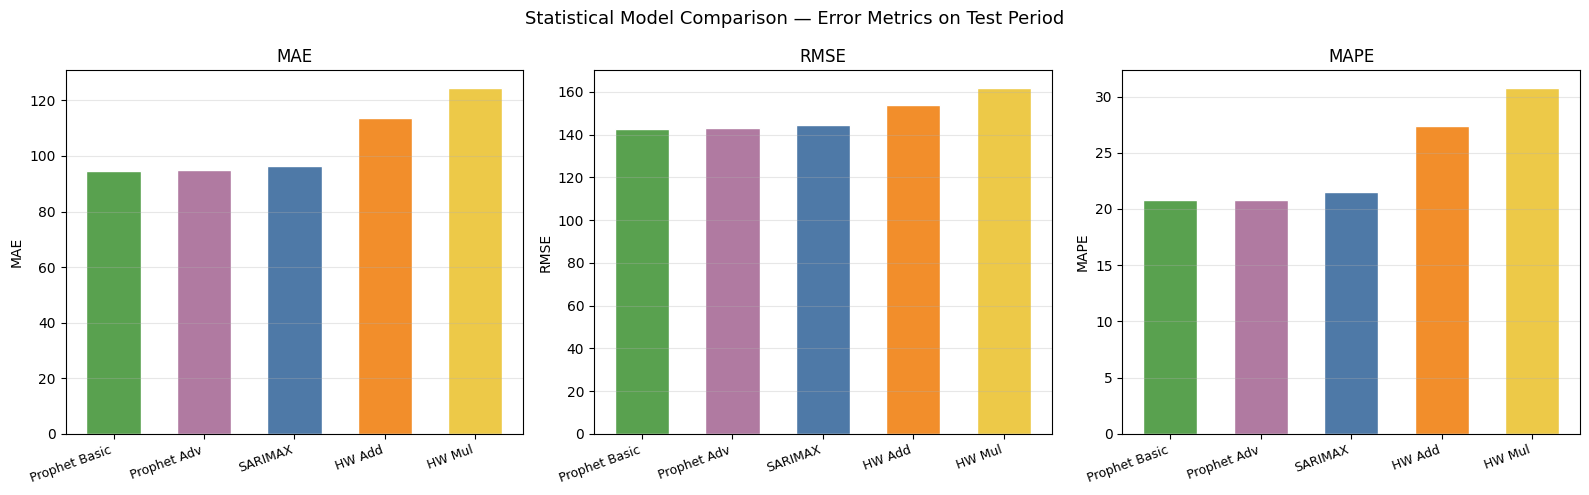

In [294]:
# Visualise the comparison with a grouped bar chart

metrics = ["MAE", "RMSE", "MAPE"]
x = range(len(results_df))

model_labels = results_df["Model"].replace({
    "SARIMAX + exogenous features": "SARIMAX",
    "Holt-Winters Additive": "HW Add",
    "Holt-Winters Multiplicative": "HW Mul",
    "Prophet Basic": "Prophet Basic",
    "Prophet Advanced": "Prophet Adv"
}).tolist()

model_color_map = {
    "SARIMAX + exogenous features": "#4E79A7",
    "Holt-Winters Additive": "#F28E2B",
    "Holt-Winters Multiplicative": "#EDC948",
    "Prophet Basic": "#59A14F",
    "Prophet Advanced": "#B07AA1"
}

model_colors = results_df["Model"].map(model_color_map).tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(metrics):
    axes[i].bar(
        x,
        results_df[metric],
        color=model_colors,
        edgecolor="white",
        width=0.6
    )
    axes[i].set_title(metric)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(model_labels, rotation=20, ha="right", fontsize=9)
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis="y")

plt.suptitle("Statistical Model Comparison — Error Metrics on Test Period", fontsize=13)
plt.tight_layout()
plt.show()

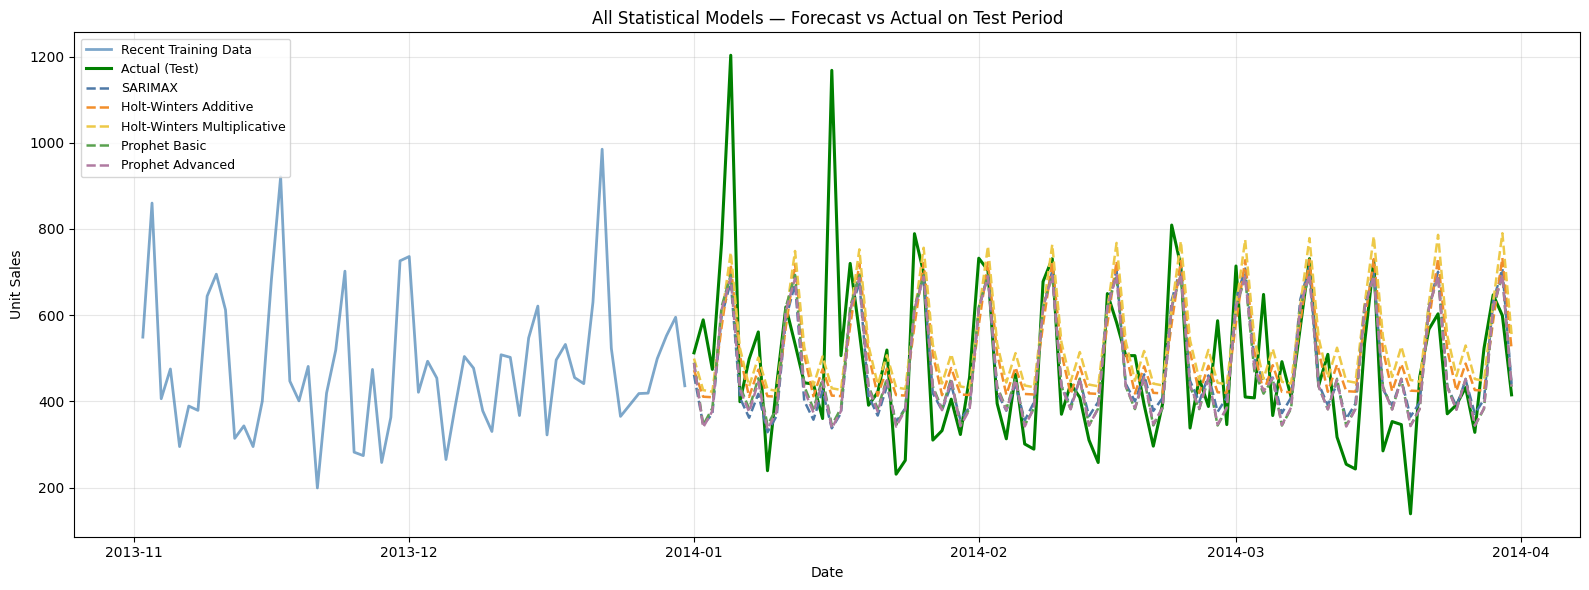

In [293]:
# Plot all statistical model forecasts on one chart for visual comparison

plt.figure(figsize=(16, 6))

plt.plot(
    train.index[-60:],
    train["unit_sales"].iloc[-60:],
    label="Recent Training Data",
    color="steelblue",
    linewidth=2,
    alpha=0.7
)

plt.plot(
    test.index,
    test["unit_sales"],
    label="Actual (Test)",
    color="green",
    linewidth=2.2
)

plt.plot(
    test.index,
    forecast_1.values,
    label="SARIMAX",
    color="#4E79A7",
    linewidth=1.8,
    linestyle="--"
)

plt.plot(
    test.index,
    forecast_hw_add.values,
    label="Holt-Winters Additive",
    color="#F28E2B",
    linewidth=1.8,
    linestyle="--"
)

plt.plot(
    test.index,
    forecast_hw_mul.values,
    label="Holt-Winters Multiplicative",
    color="#EDC948",
    linewidth=1.8,
    linestyle="--"
)

plt.plot(
    test.index,
    prophet_basic_preds,
    label="Prophet Basic",
    color="#59A14F",
    linewidth=1.8,
    linestyle="--"
)

plt.plot(
    test.index,
    prophet_adv_preds,
    label="Prophet Advanced",
    color="#B07AA1",
    linewidth=1.8,
    linestyle="--"
)

plt.title("All Statistical Models — Forecast vs Actual on Test Period")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

After correcting the cleaned time series to include a continuous daily timeline, all statistical models were rerun on the same 90-day test period from 2014-01-01 to 2014-03-31.

The final comparison shows that the Basic Prophet model achieved the best overall performance among the statistical models. It produced the lowest MAE and RMSE and the highest R² score. The Advanced Prophet model performed very similarly, but the additional oil price regressor and more flexible setup did not lead to a meaningful improvement in forecast accuracy.

SARIMAX with exogenous features also performed competitively, but it was slightly weaker than Basic Prophet on the corrected test period. Holt-Winters performed worse than both Prophet and SARIMAX, suggesting that simple exponential smoothing was less effective for this dataset.

Overall, Basic Prophet is selected as the strongest statistical benchmark model in this notebook. This result will be used later as a reference point when comparing statistical models with machine learning models based on engineered features.